In [58]:
import pandas as pd
from collections import Counter
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

In [4]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'fraktionslos']

In [9]:
df_interruptions = pd.read_csv('./data/comments.csv')
df_interruptions.head(-20)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der W...,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist doch die erste Lesung!,CDU/CSU,<unknown>,DIE LINKE,Dr. Barbara Höll,1991-03-12,11,2
3,3,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
4,4,Gebt erst mal das Vermögen der PDS dem Staat ...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
...,...,...,...,...,...,...,...,...,...
467898,467898,Was ist jetzt hier der Unterschied zwischen A...,CDU/CSU,Markus Grübel,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467899,467899,Es gilt das Völkerrecht!,CDU/CSU,<unknown>,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467900,467900,Ach!,AfD,<unknown>,SPD,Emily Vontz,2024-05-16,33,223493
467901,467901,Oijoijoi!,SPD,Brian Nickholz,CDU/CSU,Anne König,2024-05-16,30,223494


Einige (wenige) Felder sind leider leer aus den Protokollen geparst worden. Die nehmen wir jetzt heraus.

In [28]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions[non_string_entries]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id


In [29]:
df_interruptions= df_interruptions[~non_string_entries]

In [27]:
texts_per_party = df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: ' '.join(x))

In [50]:
def get_ngrams(text, n):
    tokens = word_tokenize(text)
    return list(ngrams(tokens, n))

ngrams_data = {}
for party, text in texts_per_party.items():
    print(party)
    unigrams = get_ngrams(text, 1)
    bigrams = get_ngrams(text, 2)
    trigrams = get_ngrams(text, 3)
    
    ngrams_data[party] = {
        'unigrams': Counter(unigrams),
        'bigrams': Counter(bigrams),
        'trigrams': Counter(trigrams)
    }

AfD


KeyboardInterrupt: 

In [40]:
# Displaying the results
for party, ngram_counts in ngrams_data.items():
    print(f"Partei: {party}")
    print(f"Häufigste unigramme:{ ngram_counts['unigrams'].most_common(10)}")
    print(f"Häufigste bigramme: {ngram_counts['bigrams'].most_common(10)}")
    print(f"Häufigste trigramme: {ngram_counts['trigrams'].most_common(10)}")
    print()

Partei: AfD
Häufigste unigramme:[(('!',), 33654), (('Sie',), 8531), ((',',), 6733), (('Das',), 5536), (('?',), 4637), (('ist',), 4540), (('nicht',), 4000), (('die',), 3505), (('das',), 2946), (('doch',), 2784)]
Häufigste bigramme: [(('!', 'Das'), 4818), (('Das', 'ist'), 2263), (('!', 'Sie'), 2234), (('!', 'Die'), 1277), (('nicht', '!'), 1201), (('!', 'Ja'), 1016), (('!', 'Was'), 836), (('Ja', ','), 791), (('!', 'Wir'), 719), ((',', 'Herr'), 716)]
Häufigste trigramme: [(('!', 'Das', 'ist'), 1964), (('!', 'Ja', ','), 694), (('!', 'Sie', 'haben'), 514), (('!', 'Hört', '!'), 426), (('Das', 'ist', 'doch'), 393), (('!', 'Genau', '!'), 370), (('!', 'Ja', '!'), 307), (('!', 'Sie', 'sind'), 279), (('?', 'Das', 'ist'), 252), (('!', 'Das', 'war'), 249)]

Partei: CDU/CSU
Häufigste unigramme:[(('!',), 135905), (('Sie',), 27237), (('Das',), 26362), (('ist',), 24485), ((',',), 23828), (('nicht',), 17841), (('?',), 17677), (('die',), 13045), (('das',), 12181), (('doch',), 12041)]
Häufigste bigramme: [

Anscheinend ist das '!' sehr hoch im Kurs. Wie viel Prozent der Unterbrechungen enthalten denn ein Ausrufezeichen? 

In [35]:
percentage_excl_marks = df_interruptions['comment_text'].apply(lambda x:'!' in x).sum()/len(df_interruptions)*100
print(f"{percentage_excl_marks:.2f} %")

86.40 %


Die Kommentatoren wollen sich wohl anscheinend Ausdruck verleihen. Sonst würden sie ja niemanden unterbrechen

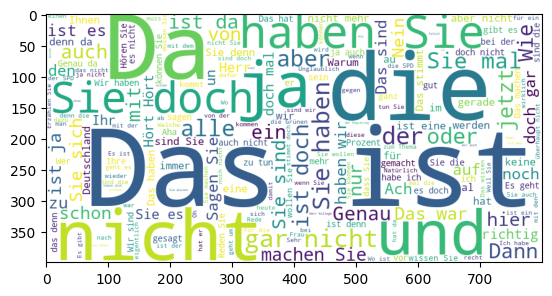

In [53]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texts_per_party['AfD'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Ein paar Stopwords dazu, damit die Ansicht aussagekräftiger wird...

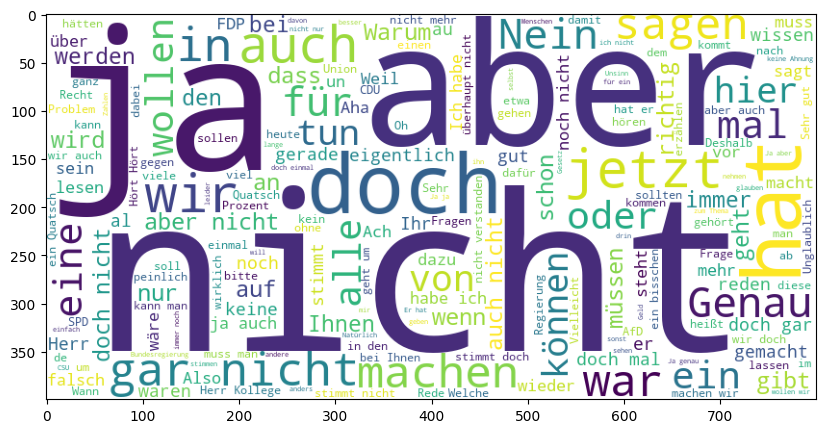

In [69]:
stopwords = ['Da', 'Sie', 'die', 'Das', 'ist', 'und', 'Dann', 'Wer', 'Wo', 'mit', 'gesagt', 'Was', 'sind', 'denn', 'haben', 'e', 'zu', 'sich', 'Ihre', 'der', 'es', 'So', 'Wie']
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(texts_per_party['GRÜNE'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Die Wortfolge Hört Hört ist wohl ziemlich beliebt...

In [63]:
df_hoert_hoert = df_interruptions[df_interruptions['comment_text'].apply(lambda x: bool(re.search('hört!? hört!?', x, flags= re.UNICODE|re.IGNORECASE)))]
df_hoert_hoert

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
341,341,Hört! Hört!,SPD,<unknown>,SPD,Ingrid Matthäus-Maier,1991-04-17,48,705
413,413,Hört! Hört!,CDU/CSU,Arnulf Kriedner,CDU/CSU,Dr. Gero Pfennig,1991-04-17,36,718
448,448,Hört! Hört!,FDP,<unknown>,CDU/CSU,Dr. Angela Merkel,1991-04-18,81,742
494,494,Hört! Hört! Da wer,SPD,Dr. Uwe Küster,CDU/CSU,Susanne Rahardt-Vahldieck,1991-04-18,65,757
534,534,Hört! Hört!,CDU/CSU,Peter Kittelmann,CDU/CSU,Horst Eylmann,1991-04-18,45,802
...,...,...,...,...,...,...,...,...,...
467585,467585,Hört! Hört!,SPD,Dr. Lina Seitzl,GRÜNE,Bruno Hönel,2024-05-16,44,223410
467627,467627,Hört! Hört! Sehr gut!,GRÜNE,Johannes Wagner,FDP,Dr. Andrew Ullmann,2024-05-16,105,223416
467827,467827,Hört! Hört!,AfD,<unknown>,CDU/CSU,Jan Metzler,2024-05-16,47,223465
467874,467874,Hört! Hört!,CDU/CSU,Nina Warken,CDU/CSU,Maria-Lena Weiss,2024-05-16,36,223482
